In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Load the datset
df = pd.read_csv("diabetes_prediction_dataset.csv")
print("Total patients :", len(df))
print()
print(df.head())

Total patients : 100000

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [ ]:
#Explore the data
print("Rows and Columns :", df.shape)
print()
print(df.dtypes)
print()
print(df.isnull().sum())
print()
print(df["diabetes"].value_counts())

Rows and Columns : (100000, 9)

gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

diabetes
0    91500
1     8500
Name: count, dtype: int64


In [ ]:
#Remove wrong rows
before = len(df)
df = df[df["gender"] != "Other"]
print("Removed gender=Other rows :", before - len(df))
print("Patients remaining         :", len(df))

Removed gender=Other rows : 18
Patients remaining         : 99982


In [ ]:
#Fix impossible Values
df.loc[df["bmi"] < 10, "bmi"] = None
df.loc[df["bmi"] > 60, "bmi"] = None
df.loc[df["blood_glucose_level"] < 30,  "blood_glucose_level"] = None
df.loc[df["blood_glucose_level"] > 500, "blood_glucose_level"] = None
df.loc[df["age"] < 0, "age"] = None
print("Impossible values fixed")
print("Missing values now :", df.isnull().sum().sum())

Impossible values fixed
Missing values now : 115


In [ ]:
#Fill empty cells
for col in ["bmi", "HbA1c_level", "blood_glucose_level", "age"]:
    average = df[col].mean()
    df[col] = df[col].fillna(average)
print("Empty cells filled with average")
print("Missing values left :", df.isnull().sum().sum())

Empty cells filled with average
Missing values left : 0


In [ ]:
#Remove duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows found :", duplicates)
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print("Patients after removing duplicates :", len(df))

Duplicate rows found : 3854
Patients after removing duplicates : 96128


In [ ]:
#Create age group column
def get_age_group(age):
    if age < 40:
        return "Young"
    elif age < 60:
        return "Middle"
    else:
        return "Senior"
df["age_group"] = df["age"].apply(get_age_group)
print(df[["age", "age_group"]].head(10))

    age age_group
0  80.0    Senior
1  54.0    Middle
2  28.0     Young
3  36.0     Young
4  76.0    Senior
5  20.0     Young
6  44.0    Middle
7  79.0    Senior
8  42.0    Middle
9  32.0     Young


In [ ]:
#Create BMI label Column
def get_bmi_label(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"
df["bmi_label"] = df["bmi"].apply(get_bmi_label)
print(df[["bmi", "bmi_label"]].head(10))

     bmi   bmi_label
0  25.19  Overweight
1  27.32  Overweight
2  27.32  Overweight
3  23.45      Normal
4  20.14      Normal
5  27.32  Overweight
6  19.31      Normal
7  23.86      Normal
8  33.64       Obese
9  27.32  Overweight


In [ ]:
#Create Glucose Risk and Risk Score
df["glucose_risk"] = "Normal"
df.loc[df["blood_glucose_level"] >= 126, "glucose_risk"] = "High"
df["risk_score"] = (
    (df["hypertension"]         == 1).astype(int) +
    (df["heart_disease"]        == 1).astype(int) +
    (df["blood_glucose_level"] >= 126).astype(int) +
    (df["bmi"]                 >= 30).astype(int)
)
print(df[["blood_glucose_level", "glucose_risk", "risk_score"]].head(10))

   blood_glucose_level glucose_risk  risk_score
0                140.0         High           2
1                 80.0       Normal           0
2                158.0         High           1
3                155.0         High           1
4                155.0         High           3
5                 85.0       Normal           0
6                200.0         High           1
7                 85.0       Normal           0
8                145.0         High           2
9                100.0       Normal           0


In [ ]:
#Remove Exact Columns
df_suppressed = df.drop(columns=["age", "bmi"])
print("Columns removed : age, bmi")
print()
print("Remaining columns :")
print(list(df_suppressed.columns))

Columns removed : age, bmi

Remaining columns :
['gender', 'hypertension', 'heart_disease', 'smoking_history', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'age_group', 'bmi_label', 'glucose_risk', 'risk_score']


In [ ]:
#K-Anonymity
k = 5
quasi_cols = ["age_group", "gender", "smoking_history"]
group_counts = df_suppressed.groupby(quasi_cols).size().reset_index(name="group_size")
df_suppressed = df_suppressed.merge(group_counts, on=quasi_cols, how="left")
before = len(df_suppressed)
df_kanon = df_suppressed[df_suppressed["group_size"] >= k].copy()
df_kanon = df_kanon.drop(columns=["group_size"])
print("k-Anonymity applied  (k = 5)")
print()
print("Patients before  :", before)
print("Patients removed :", before - len(df_kanon))
print("Patients kept    :", len(df_kanon))

k-Anonymity applied  (k = 5)

Patients before  : 96128
Patients removed : 0
Patients kept    : 96128


In [ ]:
#1-Diversity
l = 2
quasi_cols = ["age_group", "gender", "smoking_history"]

diversity = df_kanon.groupby(quasi_cols)["diabetes"].nunique().reset_index(name="unique_values")
df_kanon = df_kanon.merge(diversity, on=quasi_cols, how="left")

before = len(df_kanon)
df_ldiv = df_kanon[df_kanon["unique_values"] >= l].copy()
df_ldiv = df_ldiv.drop(columns=["unique_values"])

print("l-Diversity applied  (l = 2)")
print()
print("Patients before  :", before)
print("Patients removed :", before - len(df_ldiv))
print("Patients kept    :", len(df_ldiv))

l-Diversity applied  (l = 2)

Patients before  : 96128
Patients removed : 0
Patients kept    : 96128


In [ ]:
#Differential Policy
epsilon = 1.0

def add_noise(column, epsilon, min_val, max_val):
    noise  = np.random.laplace(0, 1/epsilon, len(column))
    result = column + noise
    result = result.clip(min_val, max_val)
    return result.round(2)

df_ldiv["HbA1c_dp"]   = add_noise(df_ldiv["HbA1c_level"],        epsilon,  3,  15)
df_ldiv["glucose_dp"] = add_noise(df_ldiv["blood_glucose_level"], epsilon, 80, 300)

print("Differential Privacy applied  (epsilon = 1.0)")
print()
print("Original vs Protected values :")
print()
print(df_ldiv[["HbA1c_level", "HbA1c_dp",
               "blood_glucose_level", "glucose_dp"]].head(8).to_string(index=False))

Differential Privacy applied  (epsilon = 1.0)

Original vs Protected values :

 HbA1c_level  HbA1c_dp  blood_glucose_level  glucose_dp
         6.6      4.43                140.0      137.34
         6.6      7.88                 80.0       80.00
         5.7      7.64                158.0      158.85
         5.0      4.90                155.0      155.52
         4.8      4.91                155.0      154.91
         6.6      3.98                 85.0       84.54
         6.5      5.26                200.0      200.40
         5.7      4.91                 85.0       85.50


In [ ]:
#Privacy Check
checks = [
    ("HbA1c_level",         "HbA1c_dp",   "HbA1c Level"),
    ("blood_glucose_level", "glucose_dp", "Blood Glucose"),
]

for orig, dp, label in checks:
    orig_avg = df_ldiv[orig].mean()
    dp_avg   = df_ldiv[dp].mean()
    diff     = abs(orig_avg - dp_avg)
    print(label)
    print("  Original average  :", round(orig_avg, 3))
    print("  Protected average :", round(dp_avg, 3))
    print("  Difference        :", round(diff, 4), " <- small is good")
    print()

HbA1c Level
  Original average  : 5.533
  Protected average : 5.603
  Difference        : 0.0703  <- small is good

Blood Glucose
  Original average  : 138.218
  Protected average : 138.248
  Difference        : 0.0304  <- small is good



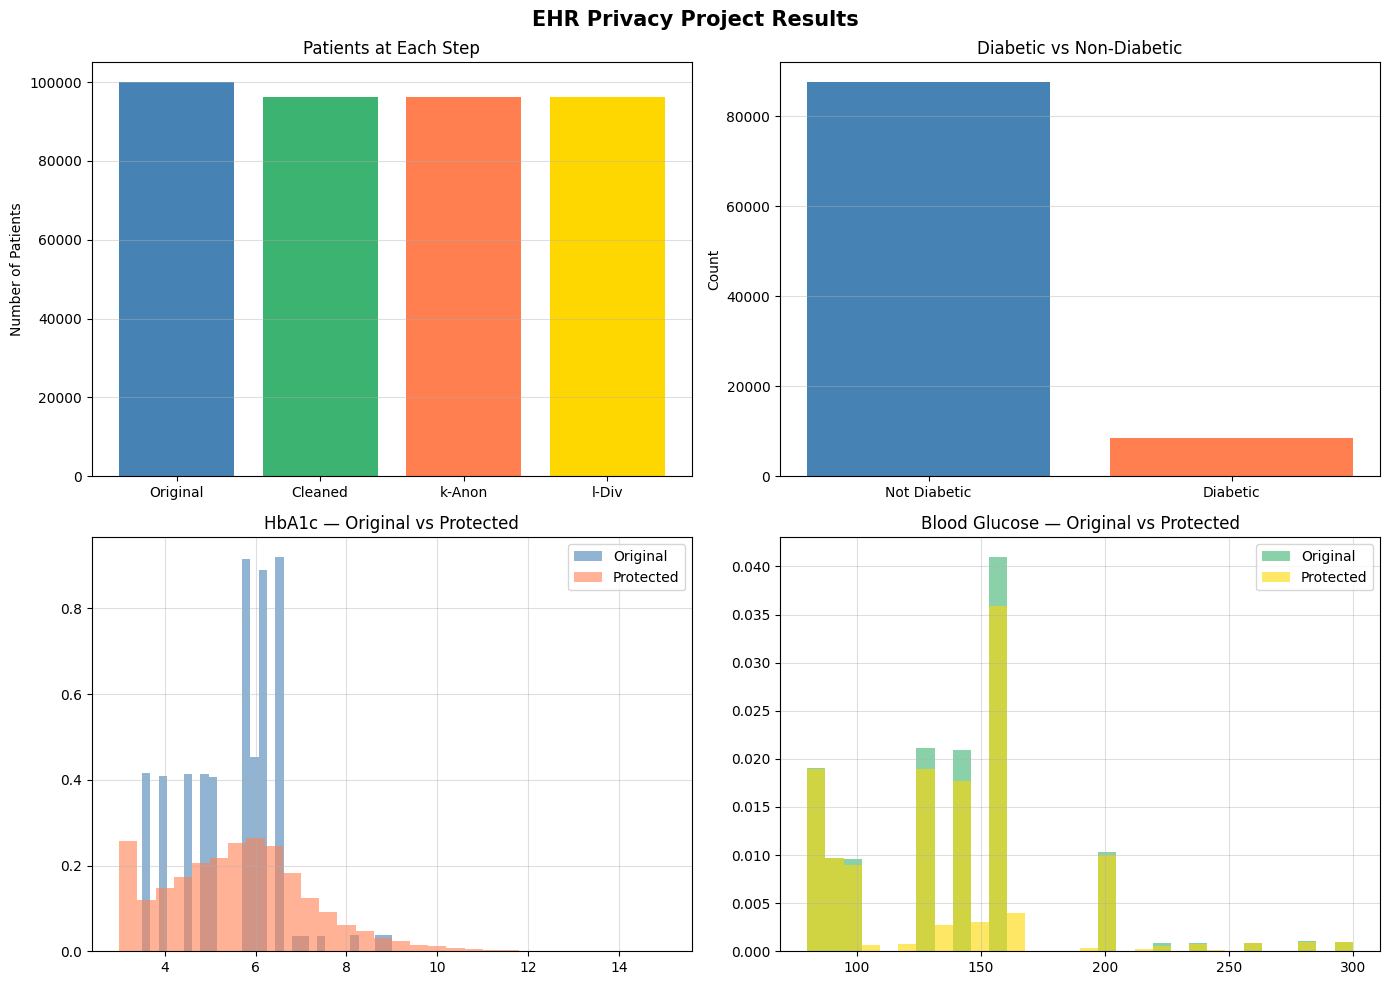

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EHR Privacy Project Results", fontsize=15, fontweight="bold")

ax = axes[0, 0]
ax.bar(["Original", "Cleaned", "k-Anon", "l-Div"],
       [100000, len(df), len(df_kanon), len(df_ldiv)],
       color=["steelblue", "mediumseagreen", "coral", "gold"])
ax.set_title("Patients at Each Step")
ax.set_ylabel("Number of Patients")
ax.grid(axis="y", alpha=0.4)

ax = axes[0, 1]
counts = df_ldiv["diabetes"].value_counts()
ax.bar(["Not Diabetic", "Diabetic"], counts.values,
       color=["steelblue", "coral"])
ax.set_title("Diabetic vs Non-Diabetic")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.4)

ax = axes[1, 0]
ax.hist(df_ldiv["HbA1c_level"], bins=30, alpha=0.6,
        color="steelblue", label="Original", density=True)
ax.hist(df_ldiv["HbA1c_dp"],   bins=30, alpha=0.6,
        color="coral",     label="Protected", density=True)
ax.set_title("HbA1c — Original vs Protected")
ax.legend()
ax.grid(alpha=0.4)

ax = axes[1, 1]
ax.hist(df_ldiv["blood_glucose_level"], bins=30, alpha=0.6,
        color="mediumseagreen", label="Original", density=True)
ax.hist(df_ldiv["glucose_dp"],          bins=30, alpha=0.6,
        color="gold",           label="Protected", density=True)
ax.set_title("Blood Glucose — Original vs Protected")
ax.legend()
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# Save the final protected dataset as a CSV file
df_ldiv.to_csv("diabetes_final_protected.csv", index=False)

# Print the final summary of everything we did
print("FINAL PIPELINE SUMMARY")
print("=" * 40)
print("Step 1 - Original dataset  : 100,000 rows")
print("Step 2 - After cleaning    :", len(df), "rows")
print("Step 3 - After suppression :", len(df_suppressed), "rows")
print("Step 4 - After k-Anonymity :", len(df_kanon), "rows")
print("       - After l-Diversity :", len(df_ldiv), "rows")
print("       - After DP noise    :", len(df_ldiv), "rows")
print()
print("File saved as diabetes_final_protected.csv ✅")
print()
print("To download the file:")
print("1. Click the folder icon on the LEFT side of Colab")
print("2. Right click on diabetes_final_protected.csv")
print("3. Click Download")

FINAL PIPELINE SUMMARY
Step 1 - Original dataset  : 100,000 rows
Step 2 - After cleaning    : 96128 rows
Step 3 - After suppression : 96128 rows
Step 4 - After k-Anonymity : 96128 rows
       - After l-Diversity : 96128 rows
       - After DP noise    : 96128 rows

File saved as diabetes_final_protected.csv ✅

To download the file:
1. Click the folder icon on the LEFT side of Colab
2. Right click on diabetes_final_protected.csv
3. Click Download
